# Titanic Survival EDA

In [ ]:
#Importing required libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
#Load dataset from seaborn as df
df = sns.load_dataset("titanic")
print(df)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

In [ ]:
#Filled NaN values with avg age
df["age"] = df["age"].fillna(df["age"].mean())
#Verifying age column still have NaN values?
print(df["age"].isna().any())

False


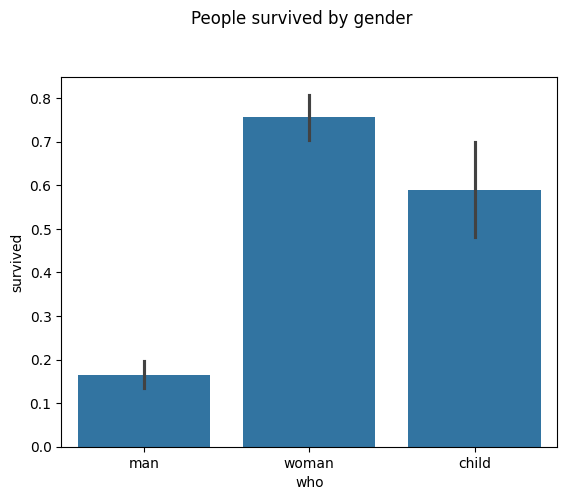




Man<Children<Woman





In [ ]:
#This plot will show who survived most
sns.barplot(data=df, x="who" , y="survived")
plt.suptitle("People survived by gender", y=1.02)
plt.show()
print("\n\n\nMan<Children<Woman\n\n\n")

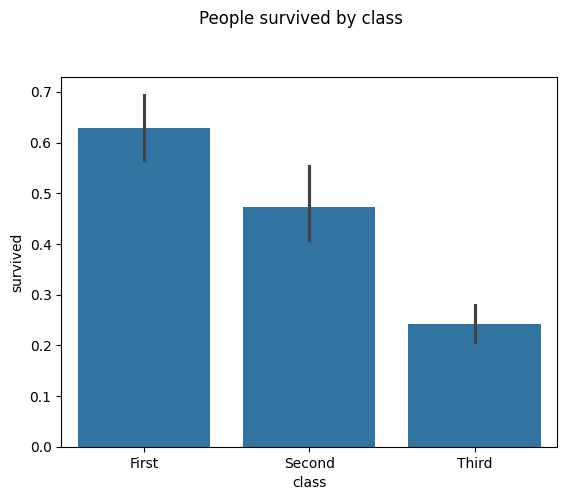




First class survival rate is high





In [ ]:
#This plot will show which class people survived most
sns.barplot(data=df, x="class" , y="survived")
plt.suptitle("People survived by class", y=1.02)
plt.show()
print("\n\n\nFirst class survival rate is high\n\n\n")

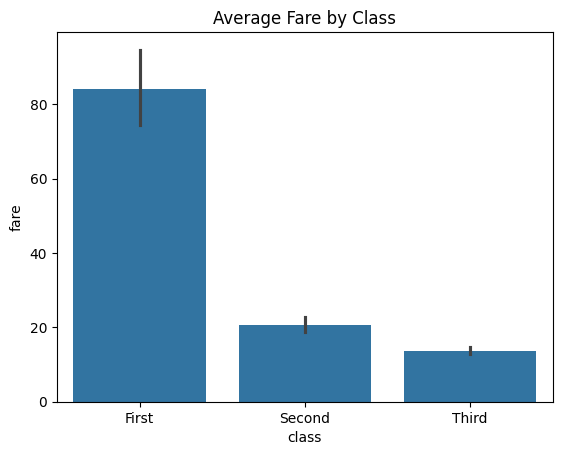




Bar plot is showing that the first class fare is high





In [ ]:
#Plot will show which class has most fare
sns.barplot(data=df, x="class", y="fare")
plt.title("Average Fare by Class")
plt.show()
print("\n\n\nBar plot is showing that the first class fare is high\n\n\n")

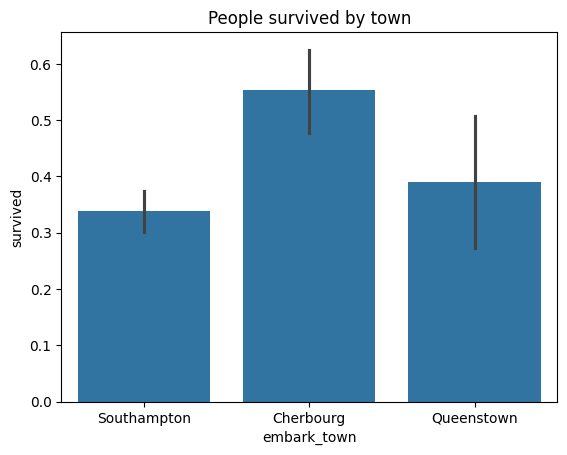





People of Cherbourg town has high survival rate


In [ ]:
# Safely fill missing embarkation data
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
#This plot will show survival rate by town
sns.barplot(data=df, x="embark_town", y="survived")
plt.title("People survived by town")
plt.show()
print("\n\n\n\nPeople of Cherbourg town has high survival rate")

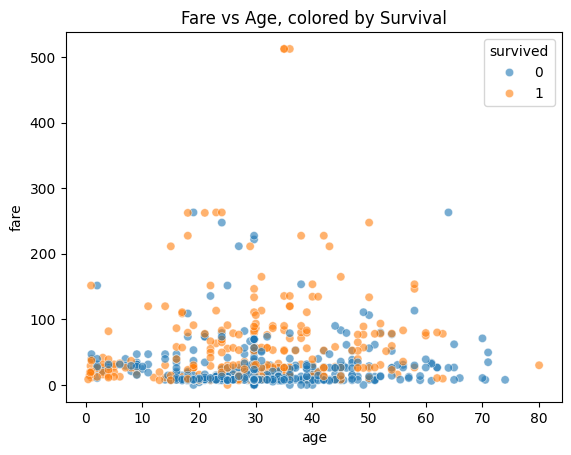

In [ ]:
#This plot will show correlation between people's survival rate by thier ages and fare
sns.scatterplot(data=df, x="age", y="fare", hue="survived", alpha=0.6)
plt.title("Fare vs Age, colored by Survival")
plt.show()

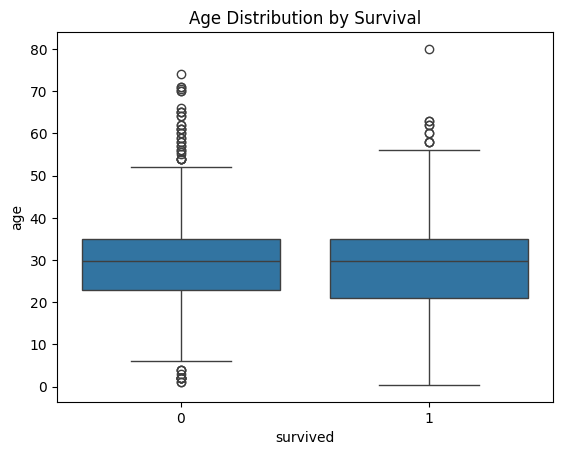

In [ ]:
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age Distribution by Survival")
plt.show()

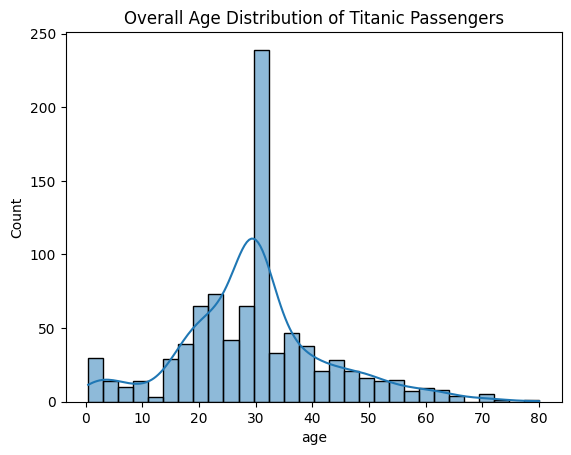

In [ ]:
#This plot will show the age count
sns.histplot(data=df, x="age", kde=True)
plt.title("Overall Age Distribution of Titanic Passengers")
plt.show()

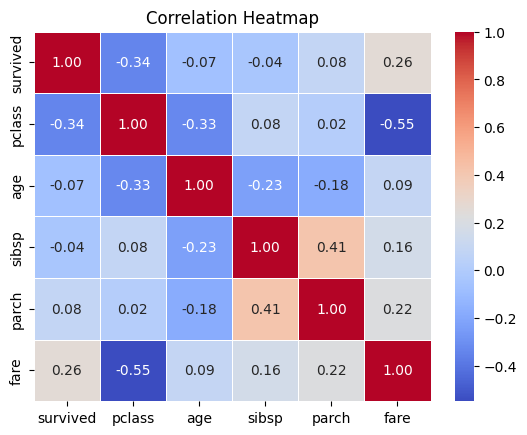

In [ ]:
#Correlation between all numeric values
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

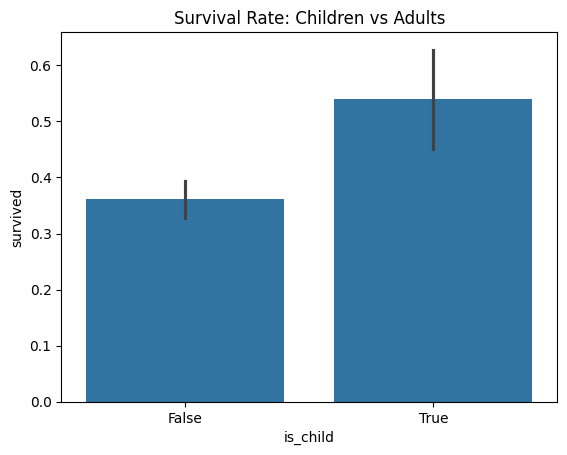

In [ ]:
#This is new column of people those age is less than 18
df["is_child"] = df["age"] < 18

#This plot will show the survival rate of people below 18
sns.barplot(data=df, x="is_child", y="survived")
plt.title("Survival Rate: Children vs Adults")
plt.show()

     survived  pclass   sex        age  sibsp  parch     fare embarked  \
0           0       3  male  22.000000      1      0   7.2500        S   
4           0       3  male  35.000000      0      0   8.0500        S   
5           0       3  male  29.699118      0      0   8.4583        Q   
6           0       1  male  54.000000      0      0  51.8625        S   
7           0       3  male   2.000000      3      1  21.0750        S   
..        ...     ...   ...        ...    ...    ...      ...      ...   
883         0       2  male  28.000000      0      0  10.5000        S   
884         0       3  male  25.000000      0      0   7.0500        S   
886         0       2  male  27.000000      0      0  13.0000        S   
889         1       1  male  26.000000      0      0  30.0000        C   
890         0       3  male  32.000000      0      0   7.7500        Q   

      class    who  adult_male deck  embark_town alive  alone  is_child  
0     Third    man        True  NaN  

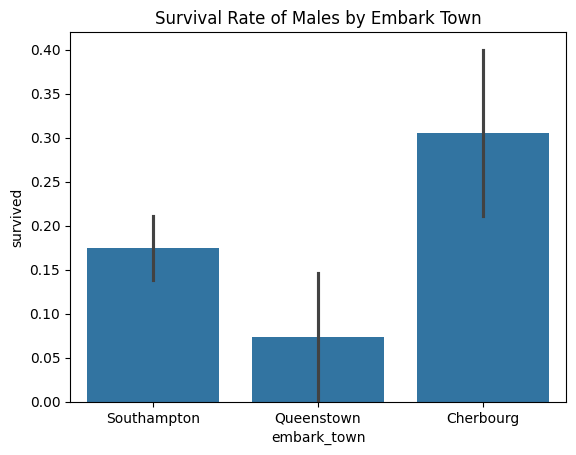

In [ ]:
#Filter only male dataset from dataframe
male_df = df[df["sex"] == "male"]

#This is bar plot of only male survival in each town
sns.barplot(data=male_df, x="embark_town", y="survived")
plt.title("Survival Rate of Males by Embark Town")
plt.show()